[INFO] Exposure (Dolma v1.7 max count):
  EU AI Act                exposure= 4370  log10(x+1)=3.64
  NIST AI RMF              exposure=  816  log10(x+1)=2.91
  Japan AI Promotion Act   exposure=   11  log10(x+1)=1.08
  Brazil PL 2338           exposure=    3  log10(x+1)=0.60
  Korean AI Basic Act      exposure=    0  log10(x+1)=0.00
[INFO] scores_all.csv: 964 rows
condition        baseline  rag
regulation                    
BR_PL2338              91   91
EU_AI_ACT             100  100
JP_AI_PROMOTION        91   91
KR_AI_BASIC_ACT       100  100
NIST_AI_RMF           100  100

[Table] Exposure summary
            Regulation  Exposure  log_Exposure  Baseline_Sgov  RAG_Sgov  Delta_Sgov  Baseline_halluc_rate                Outlier
             EU AI Act      4370         3.641          0.782     0.829       0.048                 0.020                       
           NIST AI RMF       816         2.912          0.764     0.784       0.020                 0.000                       
Jap

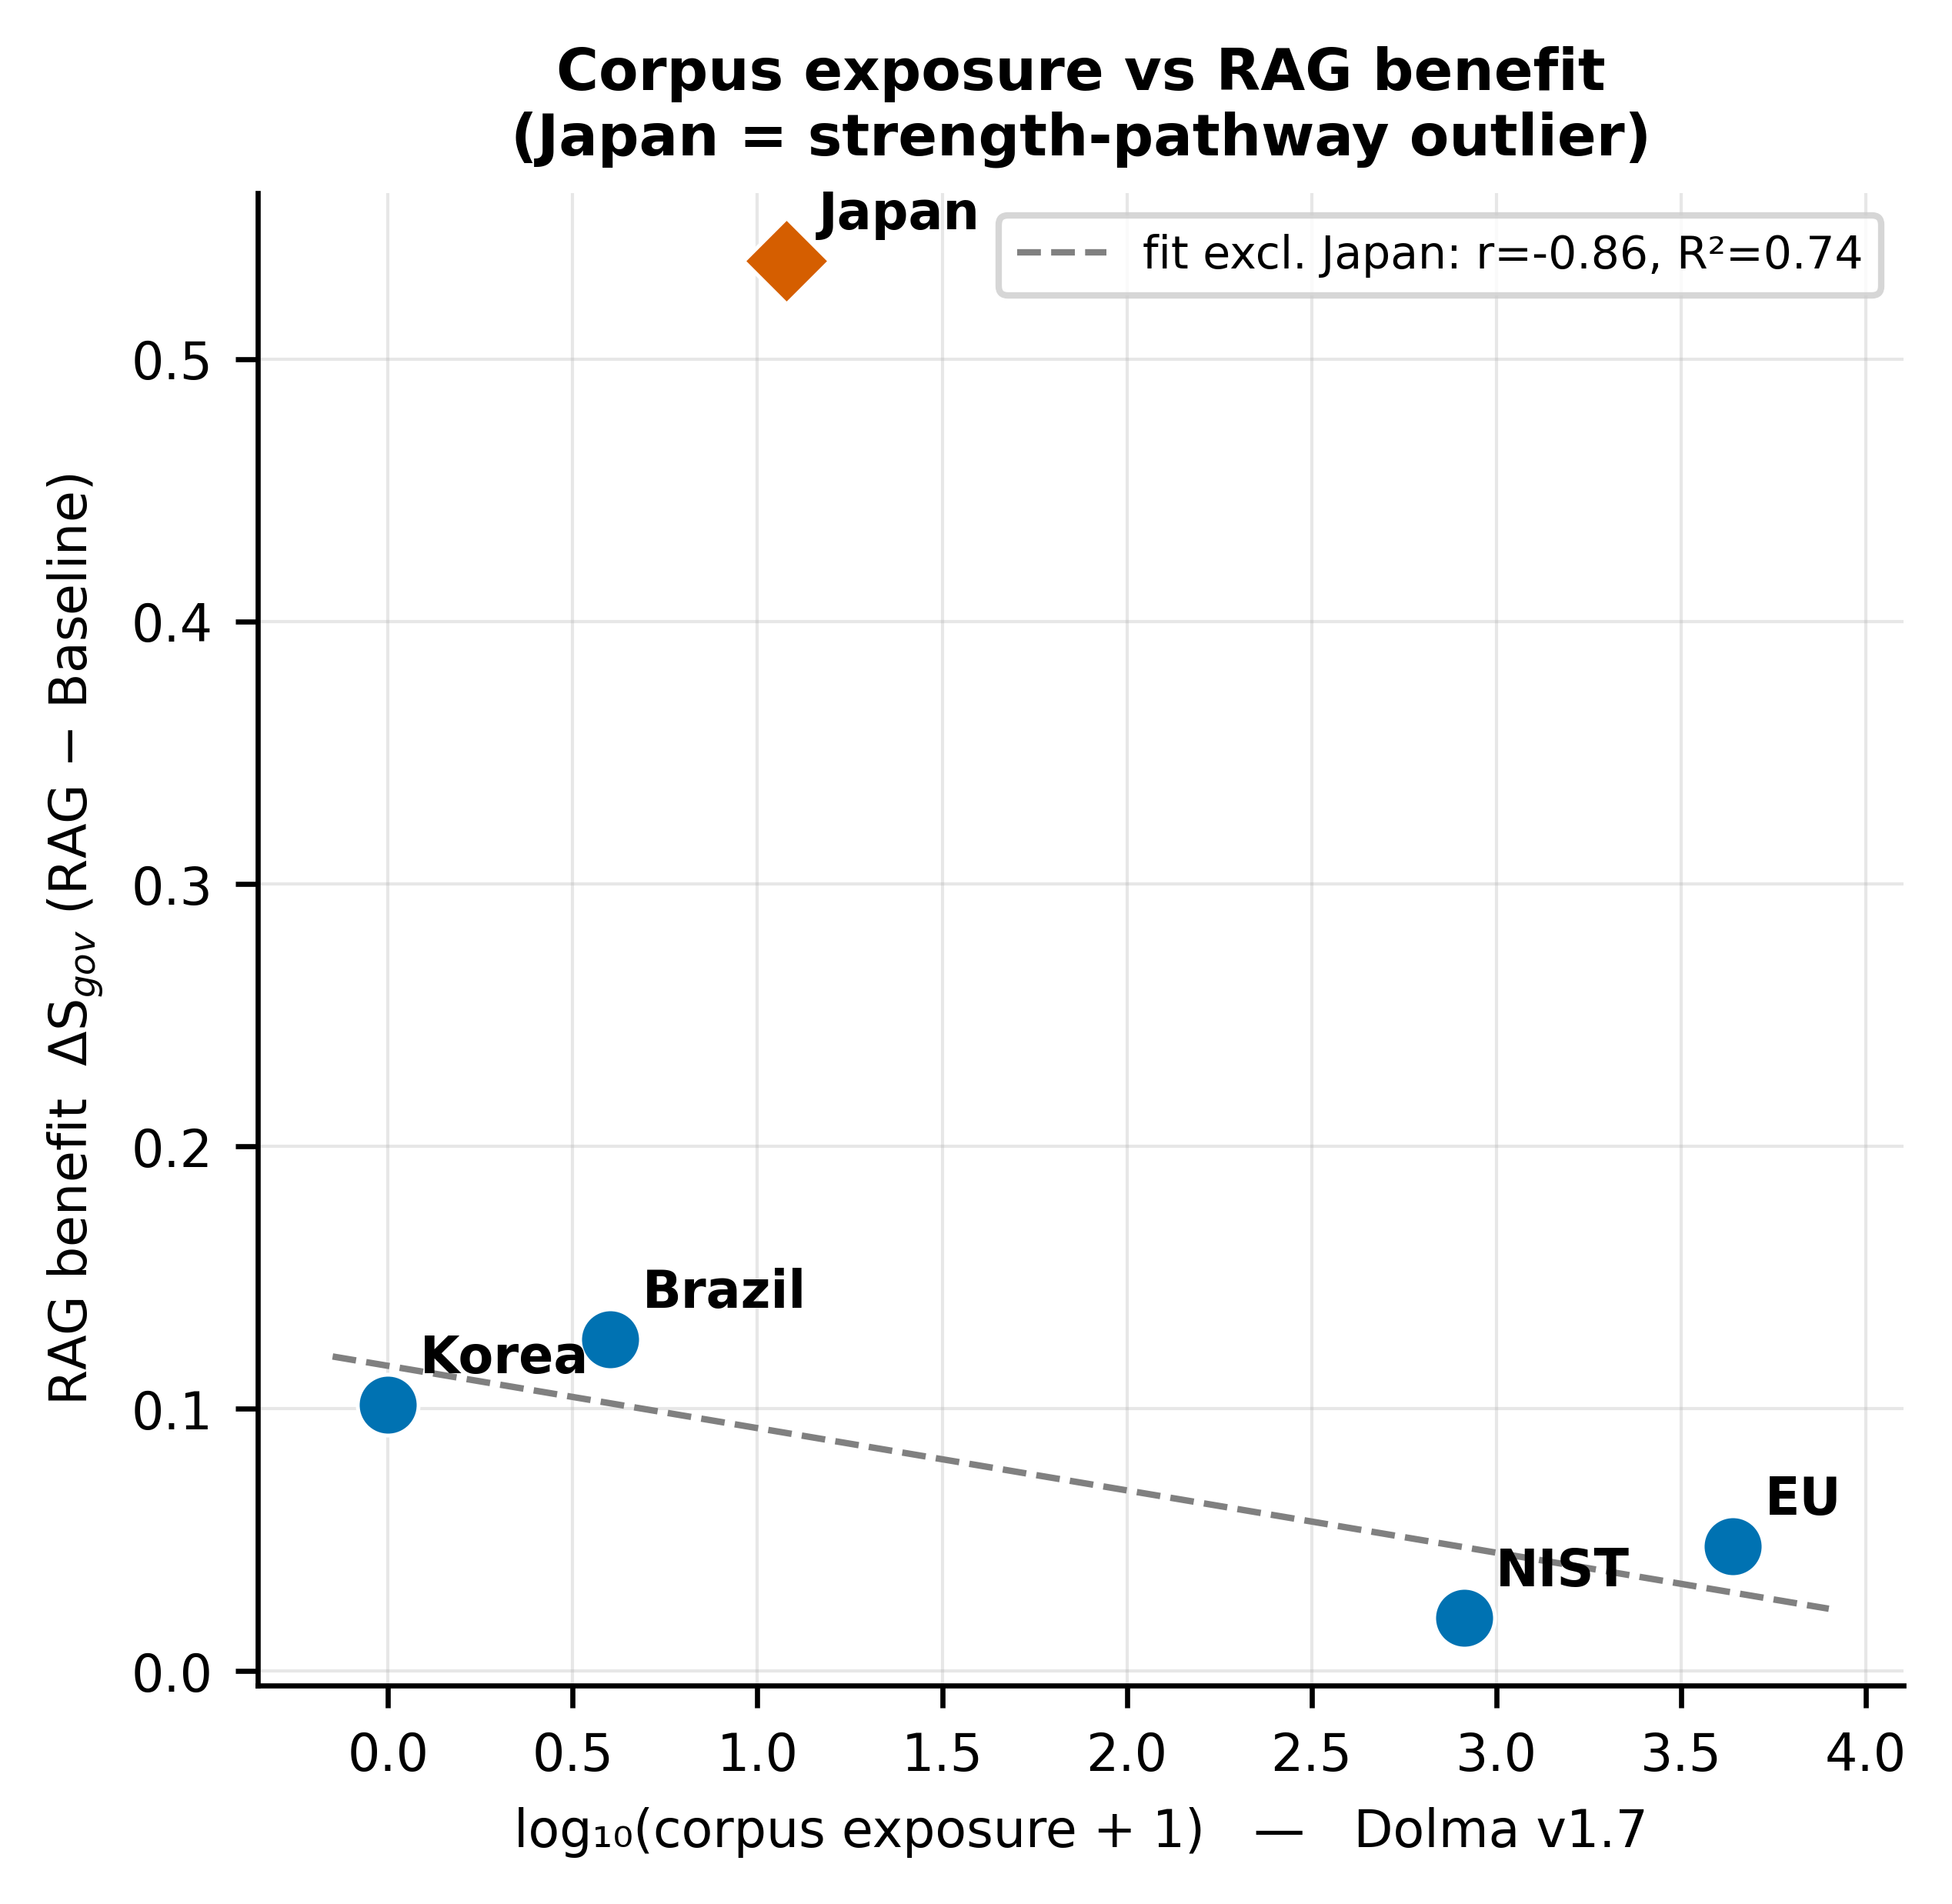

[SAVE] ../results/figures\fig14_exposure_vs_benefit_600dpi.png


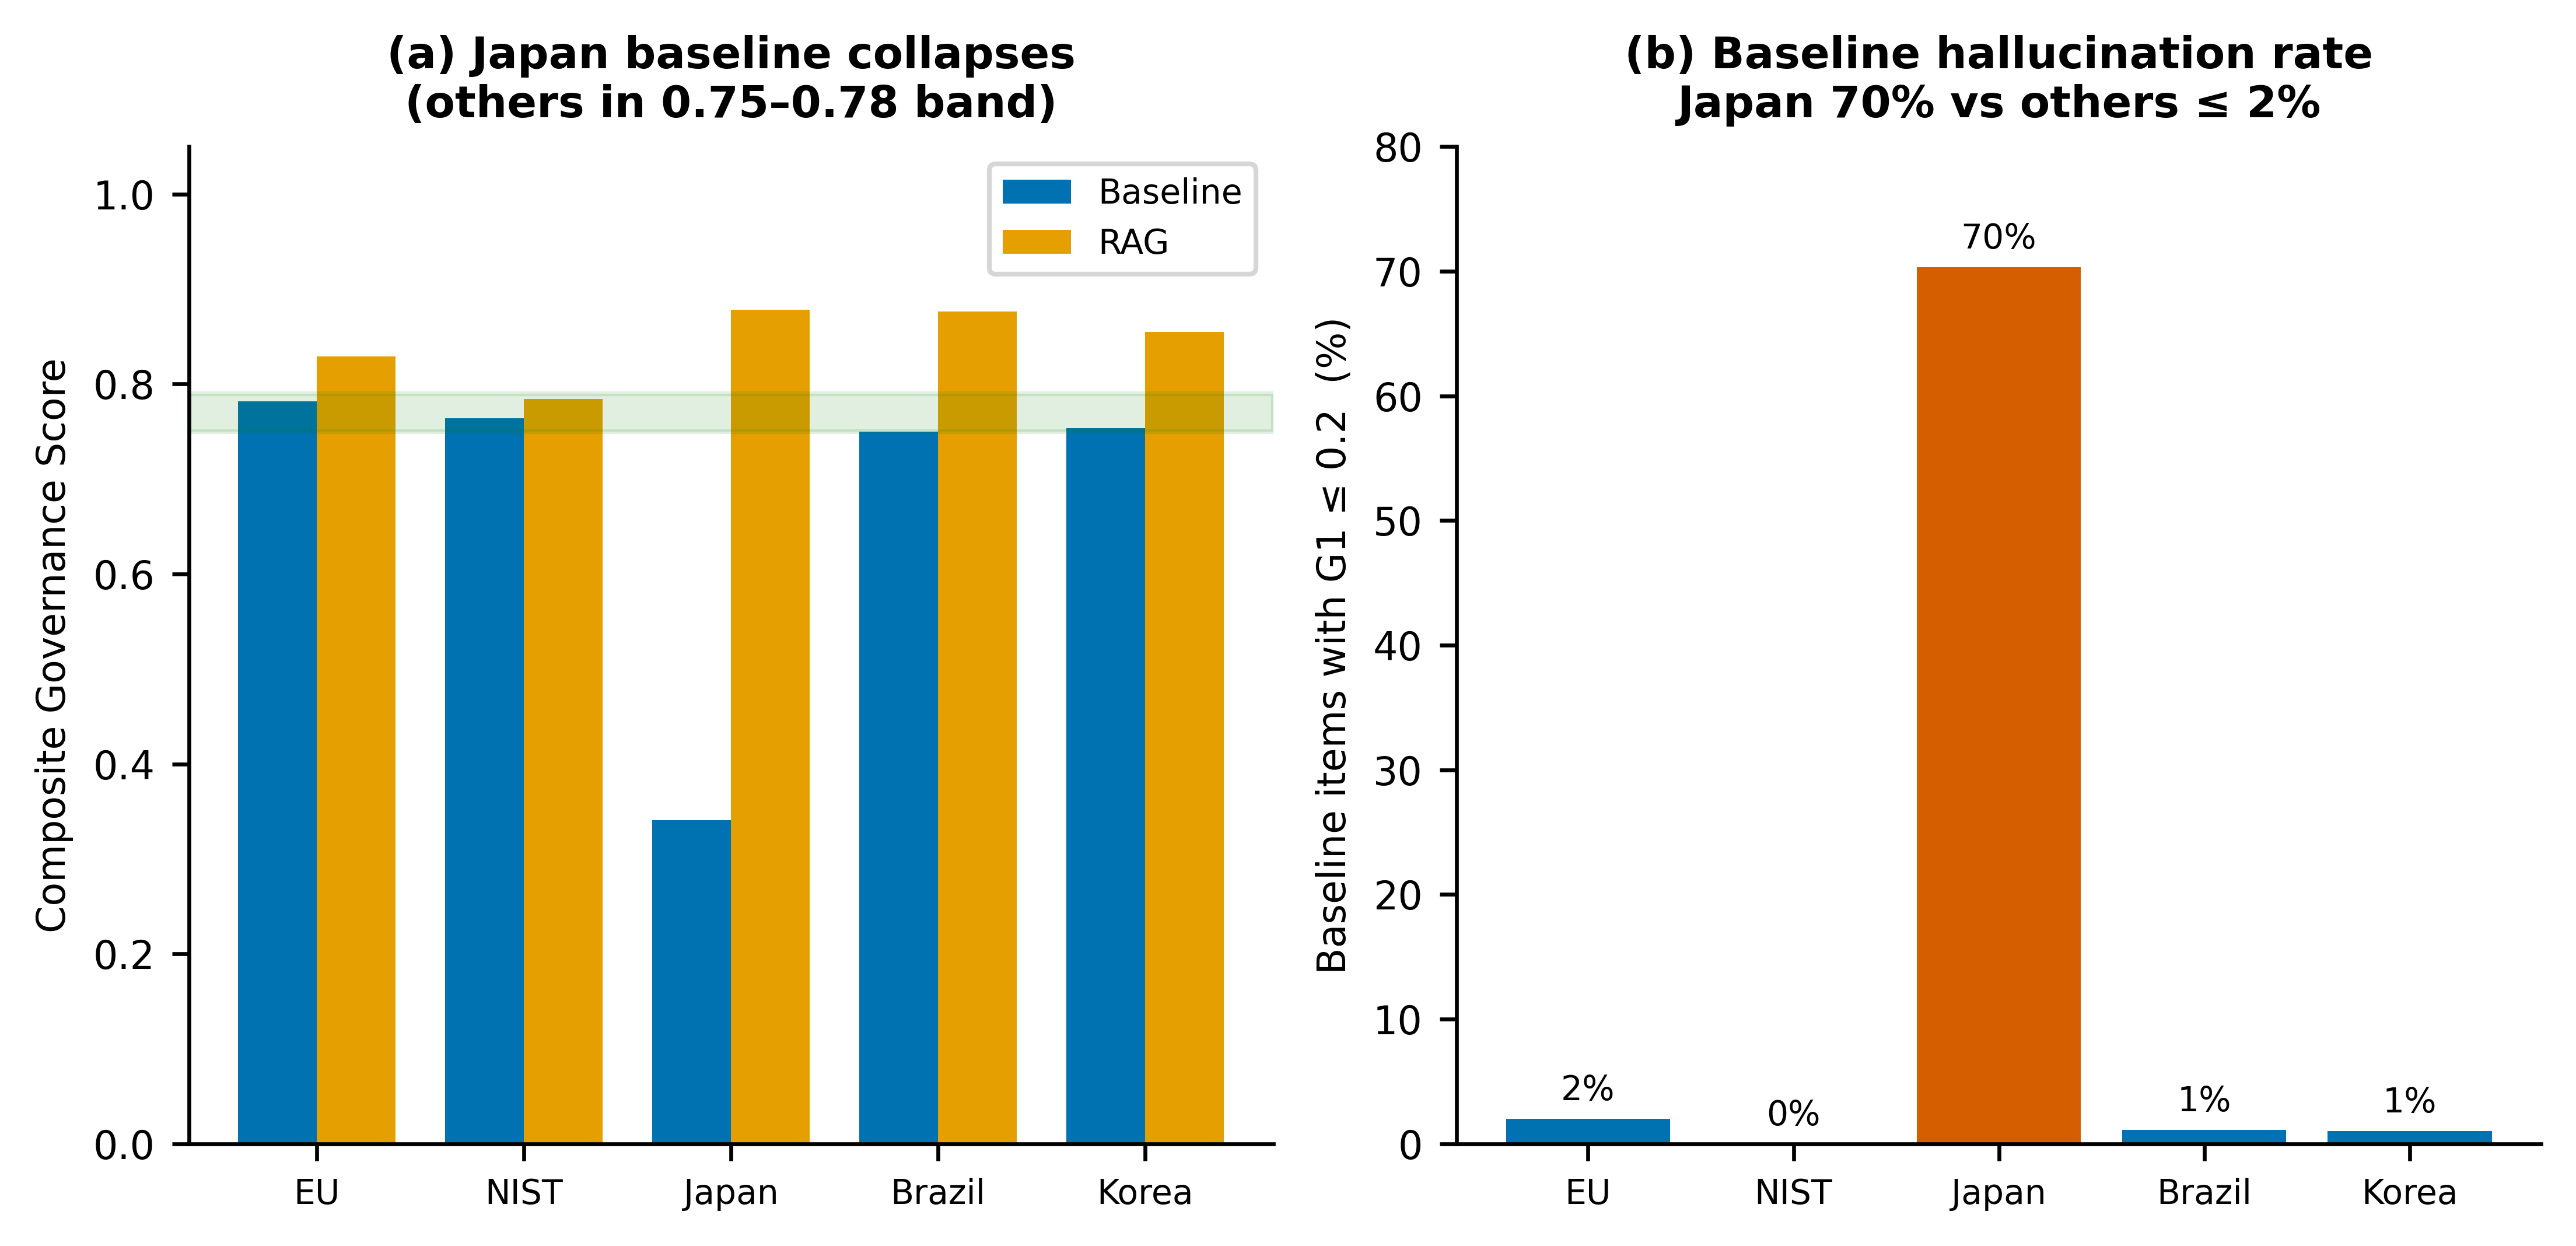

[SAVE] ../results/figures\fig15_baseline_hallucination_600dpi.png
  BRAZIL CONTROL — isolating exposure from strength

Brazil and Japan both have near-zero corpus exposure (3 vs 11), but:

  Brazil (HIGH strength: real high-risk duties, Art.17 credit, BRL 50M penalty)
    baseline Sgov = 0.750   (NORMAL — no hallucination collapse)
    baseline hallucination rate = 1.1%
    ΔSgov = +0.126   ← RAG benefit from EXPOSURE pathway (citation gap)

  Japan (LOW strength: promotional statute, no duties)
    baseline Sgov = 0.341   (COLLAPSED — hallucinates non-existent duties)
    baseline hallucination rate = 70.3%
    ΔSgov = +0.537   ← RAG benefit from STRENGTH pathway (hallucination fix)

INTERPRETATION:
  Brazil proves the exposure pathway is real and NOT a hallucination artifact:
  same low exposure as Japan, but a normal baseline, yet still a larger RAG
  benefit than the high-exposure EU/NIST. Japan's outlier ΔSgov is driven by a
  DIFFERENT mechanism (strength-induced baseline halluci

In [1]:
# %%
# =============================================================================
# 14_exposure_analysis.ipynb  [NEW]
# Financial AI Governance — Corpus-Exposure vs RAG-Benefit Analysis (Claim A)
# Kernel : Python (llm_env)
# Input  : results/scores/scores_all.csv          (964 rows: 5 regs × 2 conditions)
# Output : results/tables/table_exposure_summary.csv
#          results/tables/table_exposure_regression.csv
#          results/figures/fig14_exposure_vs_benefit_600dpi.png / .pdf
#          results/figures/fig15_baseline_hallucination_600dpi.png / .pdf
#
# Purpose (Claim A — two distinct RAG-benefit pathways):
#   (1) EXPOSURE pathway: low pre-training exposure → larger RAG benefit.
#       Evidenced by EU/NIST/Korea/Brazil (baselines all in normal 0.75-0.78
#       band); corr(log-exposure, ΔSgov) = -0.86 across these four.
#   (2) STRENGTH pathway (Japan): a promotional statute whose ground truth is
#       "no specific duty" induces systematic BASELINE HALLUCINATION (70% of
#       Japan baseline items score G1<=0.2), which RAG corrects. This is a
#       SEPARATE mechanism from exposure and Japan is treated as an outlier
#       in the exposure regression, then analysed on its own.
#
# Exposure proxy: max n-gram count of framework name/native-name/core terms
#   in Dolma v1.7 (infini-gram API). Measured externally; hard-coded below.
# =============================================================================

# %%
# =============================================================================
# Cell 1. Setup
# =============================================================================
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

SCORE_DIR  = '../results/scores'
TABLE_DIR  = '../results/tables'
FIGURE_DIR = '../results/figures'
for d in [TABLE_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

# Corpus-frequency exposure (Dolma v1.7, max over English + native-language
# names + core terms; measured via infini-gram API). See Methods.
EXPOSURE = {
    'EU_AI_ACT'      : 4370,
    'NIST_AI_RMF'    : 816,
    'JP_AI_PROMOTION': 11,
    'BR_PL2338'      : 3,
    'KR_AI_BASIC_ACT': 0,
}

REG_LABEL = {
    'NIST_AI_RMF'    : 'NIST AI RMF',
    'KR_AI_BASIC_ACT': 'Korean AI Basic Act',
    'EU_AI_ACT'      : 'EU AI Act',
    'BR_PL2338'      : 'Brazil PL 2338',
    'JP_AI_PROMOTION': 'Japan AI Promotion Act',
}
SHORT = {'EU_AI_ACT':'EU','NIST_AI_RMF':'NIST','KR_AI_BASIC_ACT':'Korea',
         'BR_PL2338':'Brazil','JP_AI_PROMOTION':'Japan'}

# Japan is analysed separately (strength pathway), excluded from exposure fit
OUTLIER = 'JP_AI_PROMOTION'

print("[INFO] Exposure (Dolma v1.7 max count):")
for r in sorted(EXPOSURE, key=lambda k:-EXPOSURE[k]):
    print(f"  {REG_LABEL[r]:24s} exposure={EXPOSURE[r]:5d}  log10(x+1)={np.log10(EXPOSURE[r]+1):.2f}")


# %%
# =============================================================================
# Cell 2. Load scores, compute per-regulation ΔSgov and hallucination proxy
# =============================================================================
df = pd.read_csv(os.path.join(SCORE_DIR, 'scores_all.csv'))
print(f"[INFO] scores_all.csv: {len(df)} rows")
print(df.groupby(['regulation','condition']).size().unstack().to_string())

g = df.groupby(['regulation','condition'])['governance_score'].mean().unstack()
g['delta'] = g['rag'] - g['baseline']

# Baseline hallucination proxy: fraction of baseline items with G1 <= 0.2
halluc = {}
for reg in EXPOSURE:
    sub = df[(df['regulation']==reg) & (df['condition']=='baseline')]
    halluc[reg] = (sub['G1_score'] <= 0.2).mean()

summary = pd.DataFrame({
    'Regulation'      : [REG_LABEL[r] for r in EXPOSURE],
    'Exposure'        : [EXPOSURE[r] for r in EXPOSURE],
    'log_Exposure'    : [round(np.log10(EXPOSURE[r]+1),3) for r in EXPOSURE],
    'Baseline_Sgov'   : [round(g.loc[r,'baseline'],3) for r in EXPOSURE],
    'RAG_Sgov'        : [round(g.loc[r,'rag'],3) for r in EXPOSURE],
    'Delta_Sgov'      : [round(g.loc[r,'delta'],3) for r in EXPOSURE],
    'Baseline_halluc_rate': [round(halluc[r],3) for r in EXPOSURE],
    'Outlier'         : ['YES (strength pathway)' if r==OUTLIER else '' for r in EXPOSURE],
}).sort_values('Exposure', ascending=False).reset_index(drop=True)

out_s = os.path.join(TABLE_DIR, 'table_exposure_summary.csv')
summary.to_csv(out_s, index=False, encoding='utf-8-sig')
print("\n[Table] Exposure summary")
print(summary.to_string(index=False))
print(f"[SAVE] {out_s}")


# %%
# =============================================================================
# Cell 3. Regression: log-exposure vs RAG benefit  (all 5 vs Japan-excluded)
# =============================================================================
def regress(regs):
    x = np.array([np.log10(EXPOSURE[r]+1) for r in regs])
    y = np.array([g.loc[r,'delta'] for r in regs])
    m, b, r, p, se = stats.linregress(x, y)
    return {'slope':m, 'intercept':b, 'r':r, 'r2':r**2, 'p':p, 'n':len(regs)}

regs_all = list(EXPOSURE)
regs_ex  = [r for r in EXPOSURE if r != OUTLIER]

fit_all = regress(regs_all)
fit_ex  = regress(regs_ex)

reg_rows = pd.DataFrame([
    {'Model':'All 5 regulations',      **{k:round(v,4) for k,v in fit_all.items()}},
    {'Model':'Excluding Japan (n=4)',  **{k:round(v,4) for k,v in fit_ex.items()}},
])
out_r = os.path.join(TABLE_DIR, 'table_exposure_regression.csv')
reg_rows.to_csv(out_r, index=False, encoding='utf-8-sig')

print("[Regression] log10(exposure+1) → ΔSgov")
print(reg_rows.to_string(index=False))
print(f"\n[INTERPRETATION]")
print(f"  Excluding Japan: r={fit_ex['r']:+.3f}, r2={fit_ex['r2']:.3f} — strong directional")
print(f"  trend (low exposure → larger RAG benefit). NOTE: n=4, p={fit_ex['p']:.3f} is")
print(f"  NOT below 0.05; report as a DIRECTIONAL PATTERN with Brazil as a clean")
print(f"  control (low exposure, normal baseline), not as a significant regression.")
print(f"[SAVE] {out_r}")


# %%
# =============================================================================
# Cell 4. Figure 14 — Exposure vs RAG benefit (Japan flagged as outlier)
# =============================================================================
plt.rcParams.update({
    'figure.dpi':600, 'savefig.dpi':600, 'font.family':'DejaVu Sans',
    'font.size':8, 'axes.titlesize':9, 'axes.titleweight':'bold',
    'axes.labelsize':8, 'axes.linewidth':0.8,
    'axes.spines.top':False, 'axes.spines.right':False,
})

fig, ax = plt.subplots(figsize=(4.6, 4.2))

for reg in EXPOSURE:
    x = np.log10(EXPOSURE[reg]+1); y = g.loc[reg,'delta']
    is_out = (reg==OUTLIER)
    ax.scatter(x, y, s=90,
               color='#D55E00' if is_out else '#0072B2',
               marker='D' if is_out else 'o',
               edgecolor='white', linewidth=0.6, zorder=3)
    ax.annotate(SHORT[reg], (x,y), xytext=(5,5),
                textcoords='offset points', fontsize=8, fontweight='bold')

# Fit line (Japan excluded)
xs = np.array([np.log10(EXPOSURE[r]+1) for r in regs_ex])
xr = np.linspace(-0.15, 3.9, 100)
ax.plot(xr, fit_ex['slope']*xr + fit_ex['intercept'],
        '--', color='gray', linewidth=1.0,
        label=f"fit excl. Japan: r={fit_ex['r']:.2f}, R²={fit_ex['r2']:.2f}")

ax.set_xlabel('log₁₀(corpus exposure + 1)   —   Dolma v1.7')
ax.set_ylabel('RAG benefit  ΔS$_{gov}$ (RAG − Baseline)')
ax.set_title('Corpus exposure vs RAG benefit\n(Japan = strength-pathway outlier)')
ax.legend(loc='upper right', fontsize=7)
ax.grid(alpha=0.3, linewidth=0.5)

out_png = os.path.join(FIGURE_DIR, 'fig14_exposure_vs_benefit_600dpi.png')
fig.savefig(out_png, dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(out_png.replace('.png','.pdf'), bbox_inches='tight', facecolor='white')
plt.show()
print(f"[SAVE] {out_png}")


# %%
# =============================================================================
# Cell 5. Figure 15 — Baseline hallucination: Japan vs the rest (strength pathway)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6))

order = sorted(EXPOSURE, key=lambda k:-EXPOSURE[k])
xlab  = [SHORT[r] for r in order]

# (a) baseline vs RAG Sgov — shows Japan's collapsed baseline
ax = axes[0]
x = np.arange(len(order)); w = 0.38
ax.bar(x-w/2, [g.loc[r,'baseline'] for r in order], w, label='Baseline', color='#0072B2')
ax.bar(x+w/2, [g.loc[r,'rag']      for r in order], w, label='RAG',      color='#E69F00')
ax.axhspan(0.75, 0.79, alpha=0.12, color='green')
ax.set_xticks(x); ax.set_xticklabels(xlab, fontsize=7)
ax.set_ylabel('Composite Governance Score'); ax.set_ylim(0,1.05)
ax.set_title('(a) Japan baseline collapses\n(others in 0.75–0.78 band)')
ax.legend(fontsize=7)

# (b) baseline hallucination rate (G1<=0.2)
ax = axes[1]
rates = [halluc[r]*100 for r in order]
bars = ax.bar(x, rates, color=['#D55E00' if r==OUTLIER else '#0072B2' for r in order])
ax.set_xticks(x); ax.set_xticklabels(xlab, fontsize=7)
ax.set_ylabel('Baseline items with G1 ≤ 0.2  (%)')
ax.set_title('(b) Baseline hallucination rate\nJapan 70% vs others ≤ 2%')
for bxx, rt in zip(bars, rates):
    ax.text(bxx.get_x()+bxx.get_width()/2, rt+1.5, f'{rt:.0f}%', ha='center', fontsize=7)
ax.set_ylim(0, 80)

plt.tight_layout()
out_png2 = os.path.join(FIGURE_DIR, 'fig15_baseline_hallucination_600dpi.png')
fig.savefig(out_png2, dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(out_png2.replace('.png','.pdf'), bbox_inches='tight', facecolor='white')
plt.show()
print(f"[SAVE] {out_png2}")


# %%
# =============================================================================
# Cell 6. Brazil control check — the clean evidence for the exposure pathway
# =============================================================================
print("="*66)
print("  BRAZIL CONTROL — isolating exposure from strength")
print("="*66)
br, jp = 'BR_PL2338', 'JP_AI_PROMOTION'
print(f"""
Brazil and Japan both have near-zero corpus exposure (3 vs 11), but:

  Brazil (HIGH strength: real high-risk duties, Art.17 credit, BRL 50M penalty)
    baseline Sgov = {g.loc[br,'baseline']:.3f}   (NORMAL — no hallucination collapse)
    baseline hallucination rate = {halluc[br]*100:.1f}%
    ΔSgov = {g.loc[br,'delta']:+.3f}   ← RAG benefit from EXPOSURE pathway (citation gap)

  Japan (LOW strength: promotional statute, no duties)
    baseline Sgov = {g.loc[jp,'baseline']:.3f}   (COLLAPSED — hallucinates non-existent duties)
    baseline hallucination rate = {halluc[jp]*100:.1f}%
    ΔSgov = {g.loc[jp,'delta']:+.3f}   ← RAG benefit from STRENGTH pathway (hallucination fix)

INTERPRETATION:
  Brazil proves the exposure pathway is real and NOT a hallucination artifact:
  same low exposure as Japan, but a normal baseline, yet still a larger RAG
  benefit than the high-exposure EU/NIST. Japan's outlier ΔSgov is driven by a
  DIFFERENT mechanism (strength-induced baseline hallucination), so it is
  reported separately rather than as an exposure data point.
""")

print("✅ Notebook 14 complete — exposure analysis (Claim A) done.")
print("   Figures: fig14 (exposure→benefit), fig15 (Japan strength pathway).")
print("   Next: 15 cross-provider evaluator (Claim B).")